In [1]:
from rich import print as pprint
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt
def show_sgm(Xc, W):
  XcW = Xc @ W # (N, n) @ (n, k) -> (N, k)
  XcWWT = XcW @ W.T  # (N, k) @ (k, n) -> (N, n)
  plt.figure(figsize=(10, 3))

  loss = F.mse_loss(Xc, XcWWT)

  plt.subplot(1, 4, 1)
  plt.matshow(W.detach(), fignum=False, vmin=-1, vmax=1)
  plt.title('W (weights)')

  plt.subplot(1, 4, 2)
  plt.matshow(Xc.detach(), fignum=False, vmin=-2, vmax=2)
  plt.title('Xc (centered data)')

  plt.subplot(1, 4, 3)
  plt.matshow(XcWWT.detach(), fignum=False, vmin=-2, vmax=2)
  plt.title('XcWWT (reconstruction)')

  plt.subplot(1, 4, 4)
  plt.matshow((Xc-XcWWT).detach(), fignum=False, vmin=-1.5, vmax=1.5)
  plt.title(f'Xc - XcWWT, loss={loss.item():.1e}')

  plt.tight_layout()
  plt.show()




=========== k = 1 =============



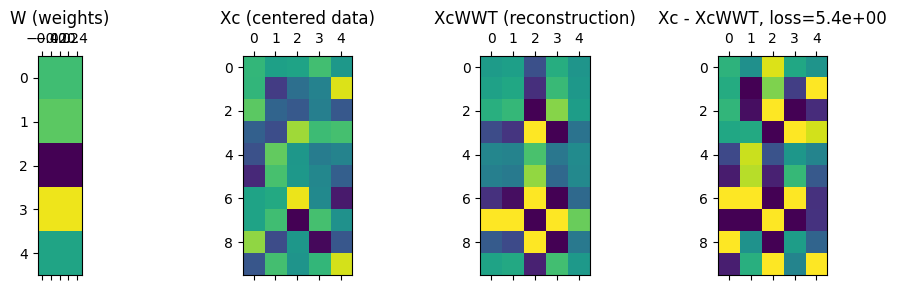

step    0  loss 5.3808264732360840
step  500  loss 0.6495394706726074
step 1000  loss 0.6384027004241943
step 1500  loss 0.6341285705566406
step 2000  loss 0.6327654719352722
step 2500  loss 0.6323751807212830
step 3000  loss 0.6322677731513977
step 3500  loss 0.6322374939918518
step 4000  loss 0.6322283148765564
step 4500  loss 0.6322256326675415
step 4999  loss 0.6322252750396729


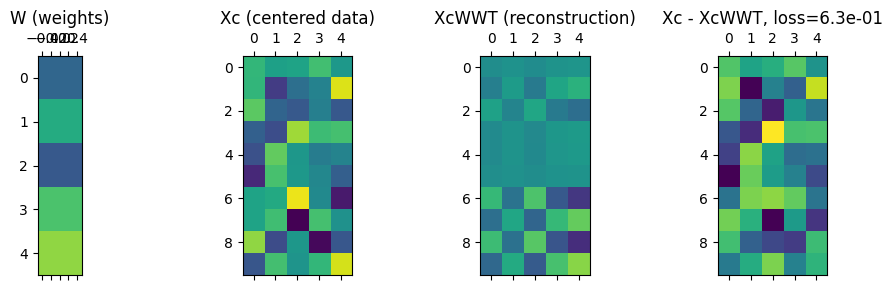

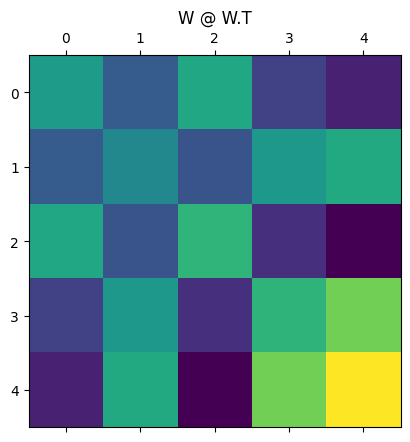



=========== k = 2 =============



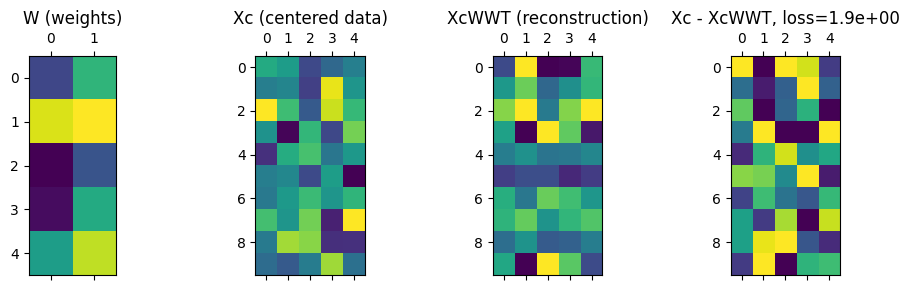

step    0  loss 1.9358142614364624
step  500  loss 0.3031879067420959
step 1000  loss 0.3031868040561676
step 1500  loss 0.3031868040561676
step 2000  loss 0.3031868040561676
step 2500  loss 0.3031868040561676
step 3000  loss 0.3031868040561676
step 3500  loss 0.3031868040561676
step 4000  loss 0.3031868040561676
step 4500  loss 0.3031868040561676
step 4999  loss 0.3031868040561676


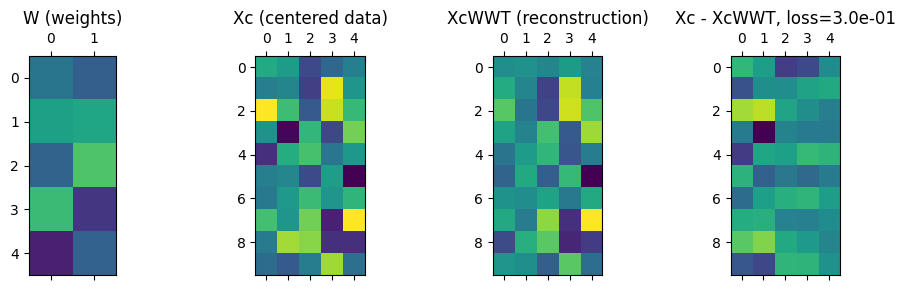

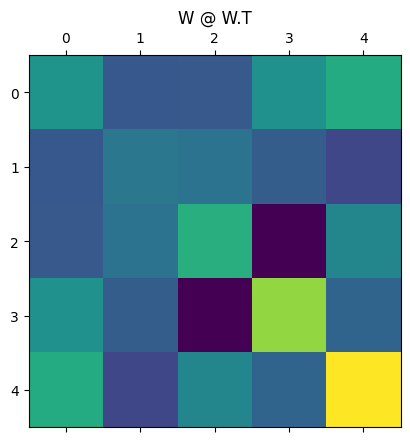



=========== k = 3 =============



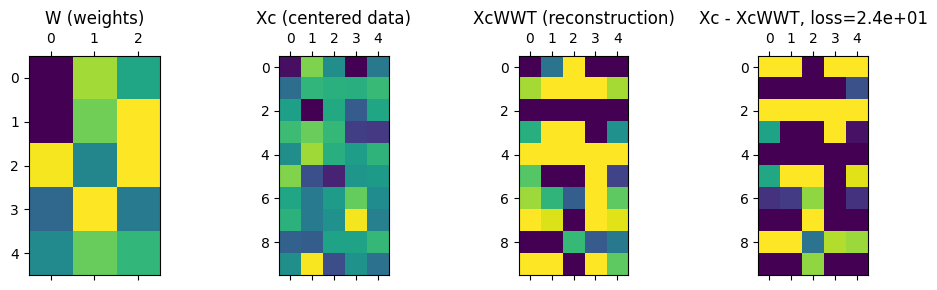

step    0  loss 23.7888011932373047
step  500  loss 0.1279221177101135
step 1000  loss 0.1070983484387398
step 1500  loss 0.1046060770750046
step 2000  loss 0.1043709591031075
step 2500  loss 0.1043533384799957
step 3000  loss 0.1043521761894226
step 3500  loss 0.1043520867824554
step 4000  loss 0.1043520867824554
step 4500  loss 0.1043520644307137
step 4999  loss 0.1043520718812943


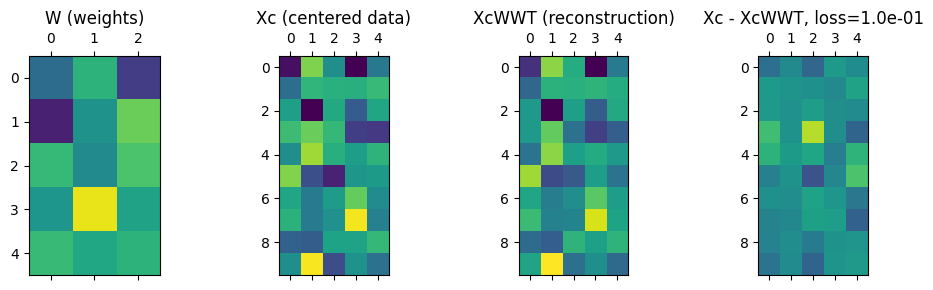

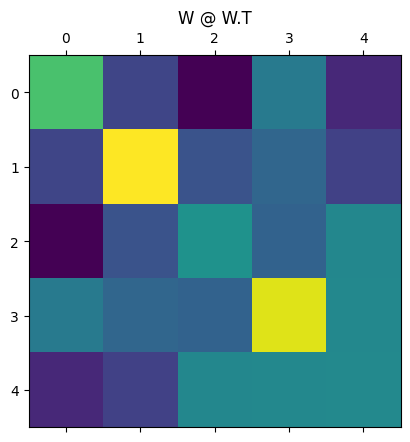



=========== k = 4 =============



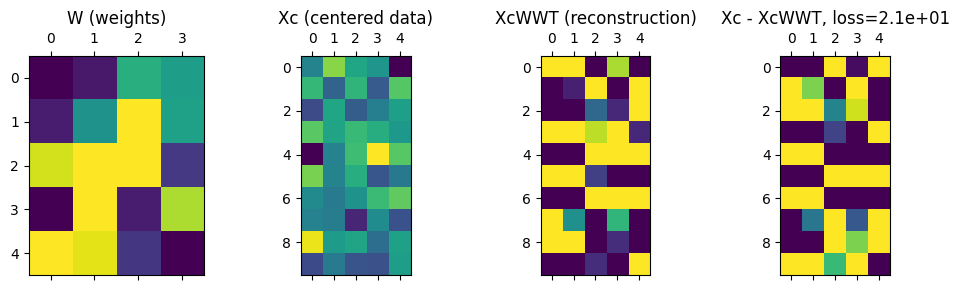

step    0  loss 20.5352878570556641
step  500  loss 0.0181481894105673
step 1000  loss 0.0171824153512716
step 1500  loss 0.0170830991119146
step 2000  loss 0.0170522648841143
step 2500  loss 0.0170450024306774
step 3000  loss 0.0170435085892677
step 3500  loss 0.0170432012528181
step 4000  loss 0.0170431323349476
step 4500  loss 0.0170431137084961
step 4999  loss 0.0170431118458509


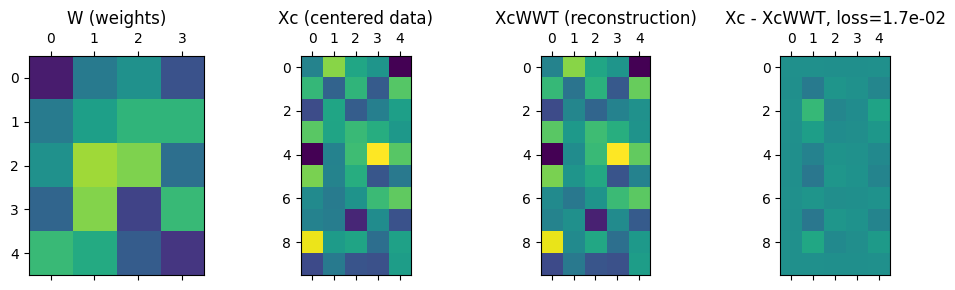

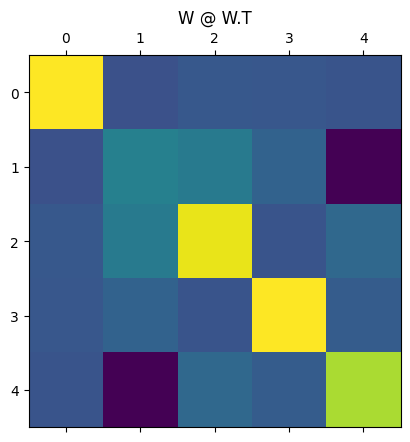



=========== k = 5 =============



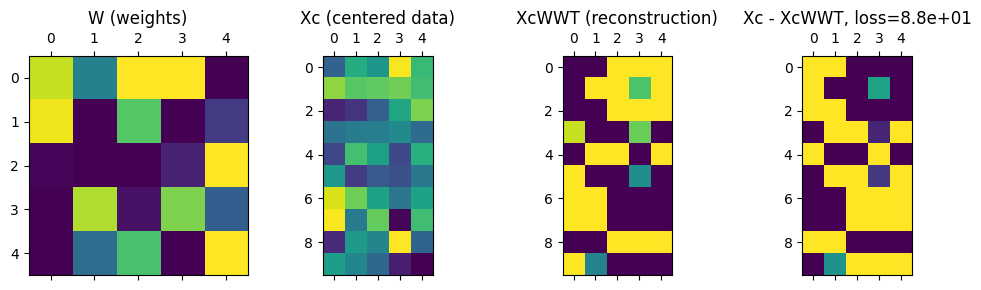

step    0  loss 88.3828430175781250
step  500  loss 0.0426505468785763
step 1000  loss 0.0010146190179512
step 1500  loss 0.0000844117530505
step 2000  loss 0.0000098602686194
step 2500  loss 0.0000011211319588
step 3000  loss 0.0000001436033017
step 3500  loss 0.0000000259209099
step 4000  loss 0.0000000080714608
step 4500  loss 0.0000000049751385
step 4999  loss 0.0000000047172874


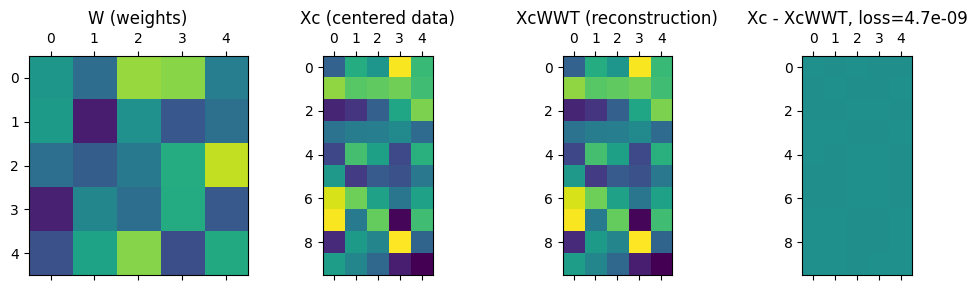

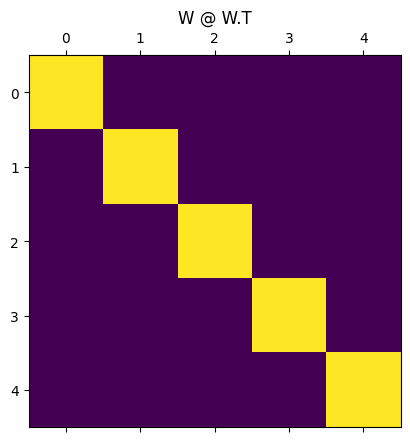

In [34]:
N = 10
n = 5  
for k in range(1,6):
    print(f"\n\n=========== k = {k} =============\n")
    X = torch.randn(N, n)
    Xc = X - X.mean(0, keepdim=True)
    W = torch.randn(n, k, requires_grad=True)

    show_sgm(Xc, W)

    steps = 5000
    opt = torch.optim.Adam([W], lr=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=steps)  

    for step in range(steps):
        XcW   = Xc @ W          # (N, k)
        XcWWT = XcW @ W.T       # (N, n)
        loss  = F.mse_loss(XcWWT, Xc)
        opt.zero_grad()
        loss.backward()
        opt.step()
        scheduler.step()
        if step % (steps // 10) == 0 or step == steps-1: print(f"step {step:4d}  loss {loss.item():.16f}")

    show_sgm(Xc, W)
    plt.matshow((W @ W.T).detach())
    plt.title('W @ W.T')
    plt.show()

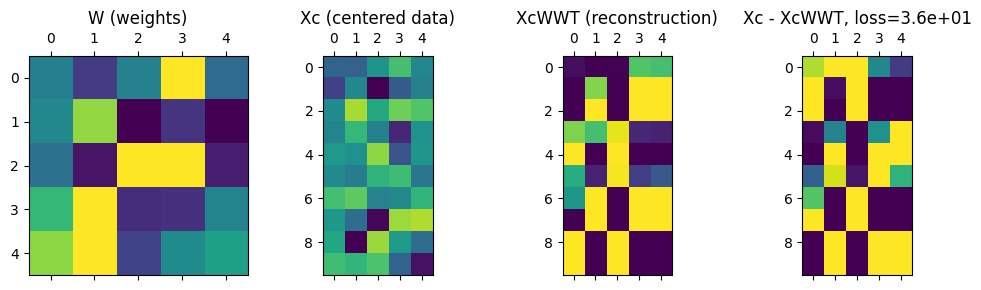

step    0  loss 35.5596199035644531
step  500  loss 0.0016749718924984
step 1000  loss 0.0000002663954035
step 1500  loss 0.0000000000155545
step 2000  loss 0.0000000000064028
step 2500  loss 0.0000000000050243
step 3000  loss 0.0000000000050147
step 3500  loss 0.0000000000050147
step 4000  loss 0.0000000000050147
step 4500  loss 0.0000000000050147
step 4999  loss 0.0000000000050147


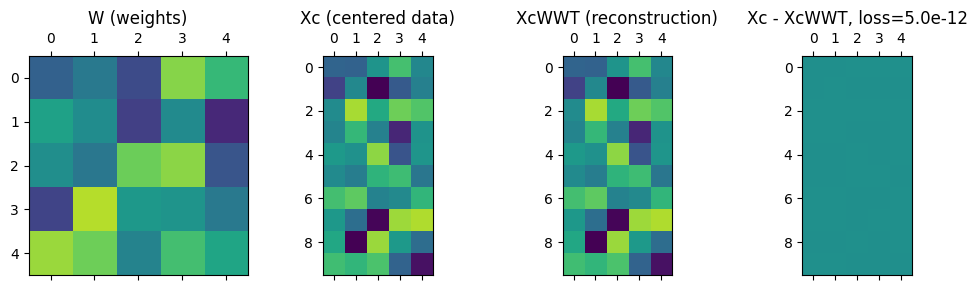

In [48]:
N = 10 
n = 5  
k = 5

X = torch.randn(N, n)
Xc = X - X.mean(0, keepdim=True)
W = torch.randn(n, k, requires_grad=True)

show_sgm(Xc, W)

steps = 5000
opt = torch.optim.Adam([W], lr=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=steps)  

for step in range(steps):
    XcW   = Xc @ W          # (N, k)
    XcWWT = XcW @ W.T       # (N, n)
    loss  = F.mse_loss(XcWWT, Xc)
    opt.zero_grad()
    loss.backward()
    opt.step()
    scheduler.step()
    if step % (steps // 10) == 0 or step == steps-1: print(f"step {step:4d}  loss {loss.item():.16f}")

show_sgm(Xc, W)

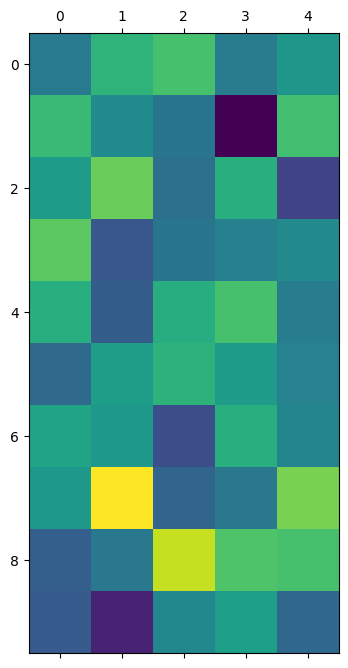

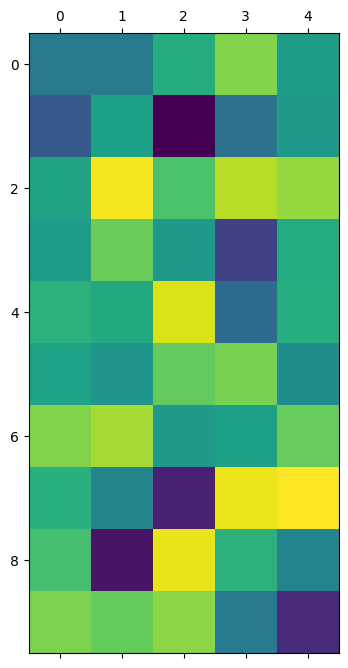

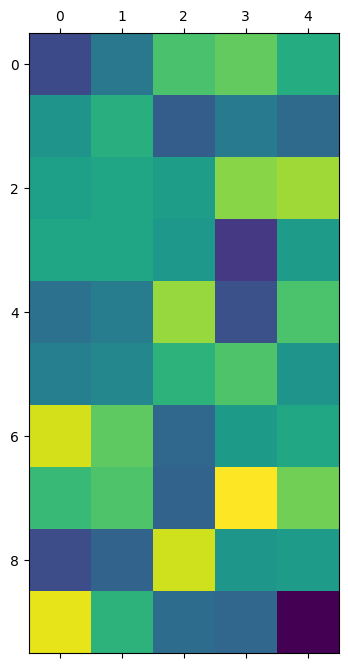

In [ ]:
XcW = Xc @ W
plt.matshow(XcW.detach())
XcWWT = XcW @ W.T
plt.matshow(XcWWT.detach())
plt.matshow((Xc - XcWWT).detach())


# HIERDIE MAAK NIE SIN NIE